In [1]:
import os
from os.path import join
import pandas as pd
from omegaconf import OmegaConf
import ast

root = "/home/ki/projects/work/mln-ood/celeb-a/multirun/2025-05-21/09-27-46/"

results = {}

for i in range(8):
    df = pd.read_csv(join(root, f"{i}/stats.csv"))
    cfg = OmegaConf.load(join(root, f"{i}/.hydra/config.yaml"))
    dataset = cfg.dataset
    best = df.loc[df['current_performance'].idxmax()]

    results[dataset] = ast.literal_eval(best["constraints:"])

In [2]:
results

{'LSUNCrop': ['blond_hair',
  'attractive',
  'blond_hair_implies_gray_hair',
  'blond_hair_implies_receding_hairline',
  'blond_hair_implies_heavy_makeup',
  'blond_hair_implies_brown_hair',
  'blond_hair_implies_mustache',
  'heavy_makeup_implies_gray_hair',
  'young_implies_not_wearing_lipstick'],
 'LSUNResize': ['gray_hair',
  'male',
  'attractive',
  'mustache_implies_not_attractive'],
 'TinyImageNetCrop': ['gray_hair',
  'male',
  'attractive',
  'mustache_implies_not_attractive'],
 'TinyImageNetResize': ['gray_hair',
  'male',
  'attractive',
  'mustache_implies_not_attractive'],
 'Places365': ['young',
  'male',
  'young_implies_attractive',
  'wearing_lipstick_implies_gray_hair',
  'not_goatee_implies_no_beard'],
 'iNaturalist': ['gray_hair',
  'young',
  'attractive',
  'no_beard',
  'gray_hair_implies_young',
  'wearing_lipstick_implies_receding_hairline',
  'male_implies_no_beard'],
 'GaussianNoise': ['gray_hair',
  'young',
  'no_beard',
  'male_implies_blond_hair',
  'ma

In [49]:
configs = {}

for dataset, constraints in results.items():
    constr_str = ""

    for constraint in constraints:
        c = f"- {constraint.replace('_implies_', ' -> ').replace('not_', 'not ')}\n"
        constr_str += c

    backbone = "resnet18"
    datasets = ["LSUNCrop", "LSUNResize", "Textures", "TinyImageNetCrop", "TinyImageNetResize", "Places365", "iNaturalist", "GaussianNoise", "UniformNoise"]

    datasets.remove(dataset)

    ds_string = ""
    for d in datasets:
        ds_string += f"- {d}\n"


    conf = f"""
defaults:
  - override hydra/job_logging: colorlog
  - override hydra/hydra_logging: colorlog

note_minded_dataset: {dataset}
n_seeds: 10
device: "cuda"

backbone: "resnet18"

use_oe: False


fit_score_dist_on: "val"
fit_score_dist: "genextreme"

paths:
  root: "/run/media/ki/data/datasets/"
  models: "/run/media/ki/data/mln-ood/celeba/models/{backbone}/"
  predictions: "/run/media/ki/data/mln-ood/celeba/predictions/{backbone}/"

constraints:
{constr_str}


datasets:
{ds_string}


attributes:
- 'blond_hair'
- 'gray_hair'
# - 'arched_eyebrows'
# - 'chubby'
#  - 'big_nose'
- 'receding_hairline'
- 'heavy_makeup'
- 'brown_hair'
  # - 'big_lips'
# - 'wavy_hair'
# - 'black_hair'
# - 'bushy_eyebrows'
# - 'pale_skin'
- 'young'
# - 'eyeglasses'
- 'wearing_lipstick'
# - 'narrow_eyes'
# - 'wearing_earrings'
# - 'oe'
# - 'high_cheekbones'
# - 'double_chin'
# - '5_o_clock_shadow'
# - 'blurry'
# - 'rosy_cheeks'
# - 'bangs'
- 'mustache'
  # - 'wearing_necklace'
- 'male'
- 'goatee'
  # - 'wearing_necktie'
# - 'oval_face'
- 'attractive'
# - 'sideburns'
- 'smiling'
  # - 'bags_under_eyes'
# - 'mouth_slightly_open'
# - 'straight_hair'
- 'bald'
- 'no_beard'
# - 'wearing_hat'
# - 'pointy_nose'
- "oe"

target_att: "brown_hair"

mln:
  train_on: "val"
  epochs: 10
  loss: "likelihood"
  batch_size: 40000
  lr: 0.01

    """

    configs[dataset] = conf


In [50]:
for dataset, conf in configs.items():
    with open(f"/home/ki/projects/work/mln-ood/celeb-a/config/test_experiments/{dataset}.yaml", "w") as f:
        f.write(conf)


In [4]:
import os
import pandas as pd
from os.path import join

root = "/home/ki/projects/work/mln-ood/celeb-a/multirun/ablation-ood-dataset/"

r = []

for d in os.listdir(root):
    df = pd.read_csv(join(root, d, "results-agg.csv"))
    print(d, df[df["Unnamed: 0"] == "MLN+Mahalanobis"].values[0,1])
    r.append({
        "dataset": d,
        "AUROC": float(df[df["Unnamed: 0"] == "MLN+Mahalanobis"].values[0,1])
    })



LSUNResize 95.38770072162151
Places365 96.46792493760586
LSUNCrop 95.8114380389452
TinyImageNetCrop 95.47122344374657
iNaturalist 95.7585097104311
GaussianNoise 94.26867708563805
UniformNoise 95.24354703724384
TinyImageNetResize 95.4998617619276


In [5]:
data = pd.DataFrame(r)

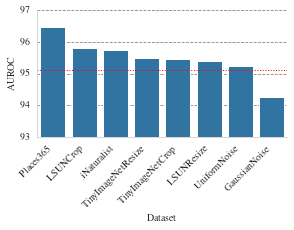

In [10]:
import seaborn as sb
import matplotlib.pyplot as plt

# Apply whitegrid with custom grid‐lines
sb.set_style("whitegrid", {
    "grid.color":     gridline_style["color"],
    "grid.linestyle": gridline_style["linestyle"],
    "grid.linewidth": gridline_style["linewidth"],
    "grid.alpha":     gridline_style["alpha"],
})

# Enable LaTeX rendering in matplotlib
plt.rcParams.update(
    {
        "text.usetex": True,  # Use LaTeX to render text
        "font.family": "serif",
        "text.latex.preamble": r"\usepackage{amsmath, amssymb}",  # Load required packages,
        "pdf.fonttype": 42,  # Ensure fonts are stored as Type 42 (TrueType) for best quality in PDFs
        "ps.fonttype": 42,
        "text.usetex": True,  # Use LaTeX for text rendering
        "font.serif": ["Times"],  # Set Times as the default serif font
    }
)



# Define grid‐line style
gridline_style = {
    "color": "gray",
    "linestyle": "--",
    "linewidth": 0.5,
    "alpha": 0.3
}



# sort your DataFrame by AUROC descending
data_sorted = data.sort_values("AUROC", ascending=False)

# create figure and axes
fig, ax = plt.subplots(figsize=(4, 3))

# draw barplot
sb.barplot(data=data_sorted, x="dataset", y="AUROC", ax=ax)

# rotate x‐tick labels, despine, etc.
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
sb.despine(ax=ax, top=True, right=True)

# set y‐limits and labels
plt.ylim(93, 97)
plt.xlabel("Dataset")

# add horizontal reference line
ax.axhline(95.12, color='red', linestyle=':', linewidth=1)

# finalize and save
plt.tight_layout(pad=0)
fig.savefig("/home/ki/ablation-ood-dataset.pdf", bbox_inches="tight")
